In [34]:
import pandas as pd
import numpy as np
from os import getcwd, listdir, path
import matplotlib.pyplot as plt
import sys
import ast
from glob import glob

In [35]:
# Read all pareto_fitness.txt files under results/causal_skills_tests and build aggregated stats
ex_name = 'common_cause_test'
base_dir = path.join('..', 'results', ex_name)
pattern = path.join(base_dir, '**', 'pareto_fitness.txt')
files = glob(pattern, recursive=True)

records = []
for fp in files:
    df = pd.read_csv(fp, sep='\t', header=None, names=['generation', 'fitness_class'])
    df[['fitness', 'class']] = pd.DataFrame(
        df['fitness_class'].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        ).tolist(),
        index=df.index,
    )
    df['run'] = path.basename(path.dirname(fp))
    records.append(df[['generation', 'fitness', 'class', 'run']])

if records:
    pareto_fitness = pd.concat(records, ignore_index=True)
else:
    pareto_fitness = pd.DataFrame(columns=['generation', 'fitness', 'class', 'run'])

# Aggregate mean/std per generation and class
pareto_stats = (
    pareto_fitness
    .groupby(['generation', 'class'])['fitness']
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .rename(columns={'mean': 'fitness_mean', 'std': 'fitness_std', 'count': 'n'})
)
pareto_stats['fitness_std'] = pareto_stats['fitness_std'].fillna(0)

print(f"Found {len(files)} pareto_fitness.txt files")
print(pareto_stats.head())
print(f"\nGenerations: {pareto_stats['generation'].min() if not pareto_stats.empty else 'NA'} to {pareto_stats['generation'].max() if not pareto_stats.empty else 'NA'}")

# Save aggregated stats to a new file csv named ex_name + '_pareto_stats.csv' and
# saved in ../results/synhesis
output_fp = path.join('..', 'results', 'synthesis', f'{ex_name}_pareto_stats.csv')
pareto_stats.to_csv(output_fp, index=False)

Found 9 pareto_fitness.txt files
   generation  class  fitness_mean  fitness_std  n
0           0     -3    -59.742964     7.764073  3
1           0     -2    -72.965532     0.355561  5
2           0     -1    -72.571047     6.477336  5
3           0      0   -151.046963   108.067186  4
4           1     -3    -58.749031     6.643706  4

Generations: 0 to 300


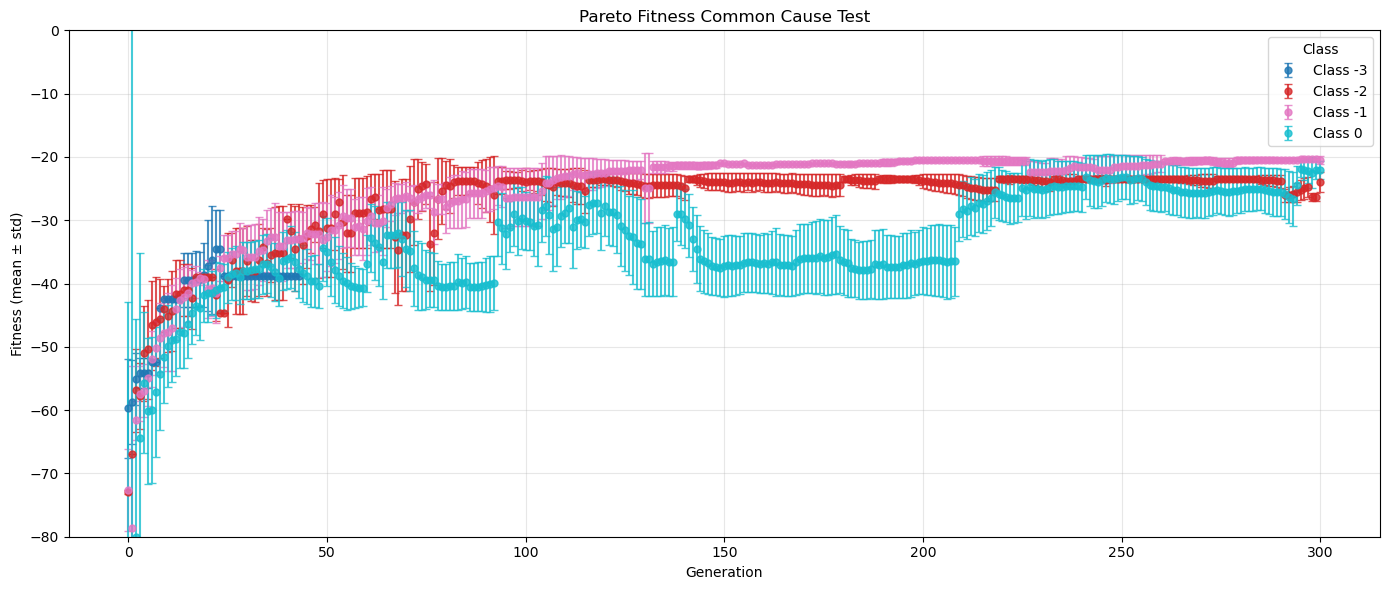

In [36]:
# Plot fitness (mean ± std) vs generation with colors corresponding to class
if pareto_stats.empty:
    print("No data to plot: no pareto_fitness.txt files found.")
else:
    fig, ax = plt.subplots(figsize=(14, 6))

    classes = sorted(pareto_stats['class'].unique())
    colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))
    color_map = {cls: colors[i] for i, cls in enumerate(classes)}

    for cls in classes:
        cls_df = pareto_stats[pareto_stats['class'] == cls]
        ax.errorbar(
            cls_df['generation'],
            cls_df['fitness_mean'],
            yerr=cls_df['fitness_std'],
            fmt='o',
            label=f'Class {cls}',
            alpha=0.8,
            markersize=5,
            color=color_map[cls],
            capsize=3,
            linestyle='None',
        )

    ax.set_xlabel('Generation')
    ax.set_ylabel('Fitness (mean ± std)')
    ax.set_title(f'Pareto Fitness {ex_name.replace("_", " ").title()}')
    ax.legend(title='Class')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-80, 0])
    plt.tight_layout()
    plt.show()

In [37]:
# find the folder that contains the best fitnes and in that folder open the folder first_front which contains files like 0.txt, 1.txt... and find the file
# that contains in the last row [best fitness, n] the best fitness and print the content of that file
# ...existing code...
# find the run folder that contains the best fitness, open its first_front/*.txt files,
# check the last non-empty row for [best_fitness, n] and print the matching file content
import math
from glob import glob

if pareto_fitness.empty:
    print("No pareto_fitness data available.")
else:
    best_idx = pareto_fitness['fitness'].idxmax()
    best_fitness = float(pareto_fitness.loc[best_idx, 'fitness'])
    best_runs = pareto_fitness[pareto_fitness['fitness'] == best_fitness]['run'].unique().tolist()
    print(f"Best fitness = {best_fitness}, candidate runs: {best_runs}")

    found = False
    for run in best_runs:
        run_dir = path.join(base_dir, run)
        ff_dirs = glob(path.join(run_dir, "**", "first_front"), recursive=True)
        for ff in ff_dirs:
            txt_files = sorted(glob(path.join(ff, "*.txt")))
            for txt_path in txt_files:
                with open(txt_path, "r") as f:
                    lines = [ln.strip() for ln in f if ln.strip()]
                if not lines:
                    continue
                try:
                    last_row = ast.literal_eval(lines[-1])
                except Exception:
                    continue
                if isinstance(last_row, (list, tuple)) and len(last_row) >= 1:
                    try:
                        val = float(last_row[0])
                    except Exception:
                        continue
                    if math.isclose(val, best_fitness, rel_tol=1e-9, abs_tol=1e-6):
                        print(f"Found matching file: {txt_path}")
                        print("---- file content ----")
                        print("\n".join(lines))
                        print("----------------------")
                        found = True
                        # Save the matching file content to a new file in ../results/synthesis
                        output_file = path.join('..', 'results', 'synthesis', f'{ex_name}_best_first_front.txt')
                        with open(output_file, 'w') as out_f:
                            out_f.write("\n".join(lines))
                        break
            if found:
                break
        if found:
            break

    if not found:
        print("No first_front/*.txt file found whose last row matches the best fitness.")
# ...existing code...

Best fitness = -20.325242477587437, candidate runs: ['Rominas-Air.lan_26_1_3_093904_385878_11205_3']
Found matching file: ../results/common_cause_test/Rominas-Air.lan_26_1_3_093904_385878_11205_3/first_front/57.txt
---- file content ----
Generation:
300
Phenotype:
6
V1 = uniform([3, 23.5], 2);
V2 = 1;
V2 = V2 + gm([1, 3, 2]);
V3 = V2;
V3 = V3 + uniform([46, 7], 2) - uniform([45, 1], 2);
Pre-processed Program
:T = uniform([3.000000, 26.500000], 2);C = 1;C = C;C = C + gm([1.000000], [3], [2]);F = C;F = F;F = F + uniform([46.000000, 53.000000], 2);F = F - uniform([45.000000, 46.000000], 2);Genotype:
[146, 203, 342, 428, 315, 45, 55, 3, 405, 227, 364, 46, 250, 434, 222, 129, 230, 103, 332, 177, 430, 231, 214, 252, 52, 110, 3, 80, 257, 88, 476, 70, 496, 17, 183, 82, 303, 227, 324, 46, 302, 483, 16, 479, 171, 303, 79, 45, 48, 135, 280, 65, 209, 124, 0, 83, 235, 191, 381, 394, 379, 446, 112, 30, 261, 71, 268, 372, 326, 349, 28, 455, 477, 384]
Tree:
None
Fitness on 5000 data:
-22.4195584871274